# Datakvalitetsanalys av PM2.5 och väderdata

**Syfte:** Undersöka datakvalitet och dokumentera möjliga åtgärder inför en modell som prognostiserar PM2.5 sex timmar framåt.

**Uppdatering:** Den ursprungliga analysen identifierade bland annat dubbla PM2.5-tidsstämplar och en observation utanför perioden. Datahämtningen har därefter korrigerats. Den här notebooken beräknar därför aktuella kontrollvärden vid körning och skiljer mellan historiska fynd och kvarvarande frågor. Resultat och grafer måste köras om mot de senaste CSV-filerna innan de tolkas som aktuella.

**Viktigt:** Interpolation med observationer på båda sidor om en lucka är användbar för vissa historiska analyser men ska inte utan vidare användas som indata till en realtidsprognos.

In [156]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()

# Gör så att Python hittar src/
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import load_config

# Läs config
CONFIG_PATH = PROJECT_ROOT / "config.toml"
config = load_config(CONFIG_PATH, PROJECT_ROOT)


# Funktion som hittar exakt en matchande fil
def find_csv(directory, pattern):
    files = list(directory.glob(pattern))

    if len(files) != 1:
        raise ValueError(
            f"Förväntade 1 fil för '{pattern}', hittade {len(files)}: {files}"
        )

    return files[0]


# Luftdata / PM2.5
air_path = find_csv(config.raw_dir, "train_*_pm25tidsserie_*.csv")
air_df = pd.read_csv(air_path)

# Väderdata
weather_path = find_csv(config.raw_dir, "train_*_vaderstationid_*.csv")
weather_df = pd.read_csv(weather_path)

# Sammanfogad data (utan tidsförskjutning)
merged_path = find_csv(config.merged_dir, "train_merged_20*.csv")
merged_df = pd.read_csv(merged_path)

# Kontrollera vilka filer som lästs in
print("PM2.5:", air_path.name)
print("Väder:", weather_path.name)
print("Merged:", merged_path.name)

PM2.5: train_Malmö_Dalaplan_2023-05-26_2025-12-31_pm25tidsserie_6247.csv
Väder: train_Malmö_A_2023-05-26_2025-12-31_vaderstationid_52350.csv
Merged: train_merged_2023-05-26_2025-12-31_pm25tidsserie_6247_vaderstationid_52350.csv


## 1. Kontroll av struktur och datatyper

**Observation:**  
Samtliga mätvariabler är numeriska (`float64`). Tidsvariabeln `tid` läses däremot in som `str` från CSV-filerna och behöver konverteras till `datetime` för vidare analys av tidsserien.

Eftersom tidsstämplarna omfattar både svensk sommartid (CEST) och vintertid (CET) konverteras `tid` till timezone-aware `datetime` (`Europe/Stockholm`). Konverteringen görs här för analysen i notebooken och hanteras även i den ordinarie datapipelinen genom `validate_data()`.

In [157]:
print("LUFTDATA")
air_df.info()

print("\nVÄDERDATA")
weather_df.info()

print("\nMERGED DATA")
merged_df.info()

for df in [air_df, weather_df, merged_df]:
    df["tid"] = (pd.to_datetime(df["tid"], utc=True)
    .dt.tz_convert("Europe/Stockholm")
    )

print(air_df["tid"].dtype)
print(weather_df["tid"].dtype)
print(merged_df["tid"].dtype)

LUFTDATA
<class 'pandas.DataFrame'>
RangeIndex: 22823 entries, 0 to 22822
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tid     22823 non-null  str    
 1   pm25    22671 non-null  float64
dtypes: float64(1), str(1)
memory usage: 356.7 KB

VÄDERDATA
<class 'pandas.DataFrame'>
RangeIndex: 22290 entries, 0 to 22289
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   tid                    22290 non-null  str    
 1   Lufttemperatur         22289 non-null  float64
 2   Vindriktning           22253 non-null  float64
 3   Vindhastighet          22253 non-null  float64
 4   Relativ luftfuktighet  22255 non-null  float64
 5   Nederbördsmängd        21756 non-null  float64
dtypes: float64(5), str(1)
memory usage: 1.0 MB

MERGED DATA
<class 'pandas.DataFrame'>
RangeIndex: 22825 entries, 0 to 22824
Data columns (total 7 columns):
 #   Column   

## 2. Kontroll av antal observationer och tidsintervall

**Förväntat antal observationer:** 22 825 timmar under perioden 2023-05-26–2025-12-31, inklusive svenska tidsomställningar.

**Observation:**

- **PM2.5-data:** Innehöll ursprungligen 22 855 observationer, vilket var fler än förväntat. Analysen visade att detta berodde på dubbla tidsstämplar vid månadsskiften samt en observation utanför träningsperioden (2026-01-01 00:00). Dessa problem har därefter åtgärdats i datahämtningen. Efter rättningen innehåller PM2.5-data 22 823 observationer. De två första timmarna i träningsperioden saknas fortfarande.

- **Väderdata:** Innehåller 22 290 observationer under den förväntade träningsperioden. Antalet är lägre än det förväntade eftersom vissa tidsstämplar saknas i väderdatan.

- **Merged data:** Innehöll ursprungligen 22 857 observationer till följd av dubbletterna och den extra tidsstämpeln i PM2.5-data. Efter rättningen innehåller den sammanfogade datan 22 825 observationer, vilket motsvarar det förväntade antalet timmar under träningsperioden.

**Slutsats:** Avvikelserna i PM2.5-datahämtningen har åtgärdats. Den sammanfogade datan har nu en komplett tidsaxel, men saknade mätvärden förekommer fortfarande och behöver undersökas separat.


In [158]:
config.train_start
config.train_slut

expected_timestamps = pd.date_range(
    start=config.train_start,
    end=f"{config.train_slut} 23:00:00",
    freq="h",
    tz="Europe/Stockholm"
)

expected_count = len(expected_timestamps)

print("Förväntat antal timmar:", expected_count)

print("Luftdata:", air_df.shape)
print("Väderdata:", weather_df.shape)
print("Merged:", merged_df.shape)

print("\nLUFTDATA")
print("Första:", air_df["tid"].min())
print("Sista:", air_df["tid"].max())

print("\nVÄDERDATA")
print("Första:", weather_df["tid"].min())
print("Sista:", weather_df["tid"].max())

print("\nMERGED")
print("Första:", merged_df["tid"].min())
print("Sista:", merged_df["tid"].max())

Förväntat antal timmar: 22825
Luftdata: (22823, 2)
Väderdata: (22290, 6)
Merged: (22825, 7)

LUFTDATA
Första: 2023-05-26 02:00:00+02:00
Sista: 2025-12-31 23:00:00+01:00

VÄDERDATA
Första: 2023-05-26 00:00:00+02:00
Sista: 2025-12-31 23:00:00+01:00

MERGED
Första: 2023-05-26 00:00:00+02:00
Sista: 2025-12-31 23:00:00+01:00


## 3. Kontroll av saknade värden

**Observation:**  
Den sammanfogade datan (merged data) har en högre andel saknade värden än respektive ursprungsdataset. Detta beror på att datakällorna delvis saknar observationer vid olika tidsstämplar. När dessa sammanfogas behålls tidsstämplarna från båda datakällorna, vilket innebär att saknade observationer i den ena datakällan representeras som `NaN` i motsvarande mätkolumner.

Detta visar att en del av de saknade värdena i merged data uppstår vid sammanfogningen, utöver de värden som redan saknas i ursprungsdatan.

In [159]:
def missing_values(df):
    return pd.DataFrame({
        "Antal saknade": df.isna().sum(),
        "Andel saknade (%)": (df.isna().mean() * 100).round(2)
    })

print("\nLUFTDATA")
print(missing_values(air_df))

print("\nVÄDERDATA")
print(missing_values(weather_df))

print("\nMERGED DATA")
print(missing_values(merged_df))


LUFTDATA
      Antal saknade  Andel saknade (%)
tid               0               0.00
pm25            152               0.67

VÄDERDATA
                       Antal saknade  Andel saknade (%)
tid                                0               0.00
Lufttemperatur                     1               0.00
Vindriktning                      37               0.17
Vindhastighet                     37               0.17
Relativ luftfuktighet             35               0.16
Nederbördsmängd                  534               2.40

MERGED DATA
                       Antal saknade  Andel saknade (%)
tid                                0               0.00
pm25                             154               0.67
Lufttemperatur                   536               2.35
Vindriktning                     572               2.51
Vindhastighet                    572               2.51
Relativ luftfuktighet            570               2.50
Nederbördsmängd                 1069               4.68


## 4. Kontroll av dubbletter

**Observation:**  
Den ursprungliga PM2.5-datan innehöll 22 855 rader jämfört med 22 825 förväntade timmar. Totalt identifierades 31 dubbla rader, samtliga med dubbla tidsstämplar. Samma dubbletter återfanns även i merged data.

Dubbletterna inträffade vid månadsskiften, klockan 00:00 den första dagen i månaden. Orsaken kunde kopplas till den månadsvisa hämtningen av PM2.5-data från API:et, där samma tidsstämpel inkluderades i två på varandra följande hämtningar.

**Åtgärd:**  
Hämtfunktionen har därefter korrigerats så att dubbla tidsstämplar tas bort och observationer utanför det angivna tidsintervallet exkluderas.

**Aktuell kontroll:**  
Efter rättningen innehåller varken PM2.5-data eller merged data några dubbla tidsstämplar. Antalet dubbletter är därmed **0** i båda dataseten.

In [160]:
duplicates = pd.DataFrame({
    "Dubbla rader": [
        air_df.duplicated().sum(),
        weather_df.duplicated().sum(),
        merged_df.duplicated().sum()
    ],
    "Dubbla tidsstämplar": [
        air_df["tid"].duplicated().sum(),
        weather_df["tid"].duplicated().sum(),
        merged_df["tid"].duplicated().sum()
    ]
}, index=["Luftdata", "Väderdata", "Merged data"])

print(duplicates)

weather_df[
    weather_df["tid"].duplicated(keep=False)
].sort_values("tid")

             Dubbla rader  Dubbla tidsstämplar
Luftdata                0                    0
Väderdata               0                    0
Merged data             0                    0


,tid,Lufttemperatur,Vindriktning,Vindhastighet,Relativ luftfuktighet,Nederbördsmängd


## 5. Kontroll av tidsluckor

**Observation:**

**Luftdata (PM2.5)**  
PM2.5-data saknar de två första förväntade tidsstämplarna i träningsperioden, 2023-05-26 kl. 00:00 och 01:00. Dessa tidsluckor kvarstår efter rättningen av datahämtningen.

**Väderdata**  
Väderdata saknar 535 tidsstämplar under träningsperioden och luckorna är ojämnt fördelade. Den längsta sammanhängande luckan omfattar 296 timmar, från 2024-08-06 kl. 06:00 till 2024-08-18 kl. 13:00.

Under vissa perioder varierar även datatillgängligheten mellan väderparametrarna. Exempelvis saknas den normala timvisa rapporteringen under delar av april 2025, medan lufttemperaturen fortfarande registreras ungefär var sjätte timme. Övriga vädervariabler saknas vid dessa tidpunkter.

Detta tyder på att luckorna åtminstone delvis beror på varierande datatillgänglighet i de underliggande väderserierna.

**Merged data**  
Den sammanfogade datan innehåller samtliga 22 825 förväntade tidsstämplar. Eftersom tidsstämplar från båda datakällorna behålls vid sammanfogningen representeras saknade observationer i respektive datakälla som `NaN`.

Det är därmed viktigt att skilja mellan **saknade tidsstämplar** och **saknade mätvärden**. En komplett tidsaxel innebär inte att samtliga mätvärden finns tillgängliga.

In [161]:
expected_timestamps = pd.date_range(
    start=f"{config.train_start} 00:00",
    end=f"{config.train_slut} 23:00",
    freq="h",
    tz="Europe/Stockholm"
)

def missing_timestamps(df):
    actual = pd.DatetimeIndex(df["tid"].drop_duplicates())
    return expected_timestamps.difference(actual)

missing_air = missing_timestamps(air_df)
missing_weather = missing_timestamps(weather_df)
missing_merged = missing_timestamps(merged_df)

print("Luftdata (PM2.5):", len(missing_air))
print("Väderdata:", len(missing_weather))
print("Merged data:", len(missing_merged))

print("Saknade tidsstämplar i luftdata:")
print(missing_air)

print("\nSaknade tidsstämplar i väderdata:")
print(missing_weather)

missing_weather_df = pd.DataFrame({
    "tid": missing_weather
})

# Ny grupp varje gång avståndet till föregående saknade tid är > 1 timme
missing_weather_df["grupp"] = (
    missing_weather_df["tid"].diff() > pd.Timedelta(hours=1)
).cumsum()

weather_gaps = (
    missing_weather_df
    .groupby("grupp")
    .agg(
        start=("tid", "min"),
        slut=("tid", "max"),
        antal_timmar=("tid", "size")
    )
    .reset_index(drop=True)
)

print(weather_gaps)

weather_april = weather_df[
    (weather_df["tid"] >= "2025-04-01") &
    (weather_df["tid"] < "2025-04-05")
]

weather_april

Luftdata (PM2.5): 2
Väderdata: 535
Merged data: 0
Saknade tidsstämplar i luftdata:
DatetimeIndex(['2023-05-26 00:00:00+02:00', '2023-05-26 01:00:00+02:00'], dtype='datetime64[us, Europe/Stockholm]', freq='h')

Saknade tidsstämplar i väderdata:
DatetimeIndex(['2023-06-08 10:00:00+02:00', '2024-08-06 06:00:00+02:00',
               '2024-08-06 07:00:00+02:00', '2024-08-06 08:00:00+02:00',
               '2024-08-06 09:00:00+02:00', '2024-08-06 10:00:00+02:00',
               '2024-08-06 11:00:00+02:00', '2024-08-06 12:00:00+02:00',
               '2024-08-06 13:00:00+02:00', '2024-08-06 14:00:00+02:00',
               ...
               '2025-07-07 05:00:00+02:00', '2025-07-07 06:00:00+02:00',
               '2025-07-07 07:00:00+02:00', '2025-07-07 09:00:00+02:00',
               '2025-07-07 10:00:00+02:00', '2025-07-07 11:00:00+02:00',
               '2025-07-07 12:00:00+02:00', '2025-07-07 13:00:00+02:00',
               '2025-07-07 15:00:00+02:00', '2025-07-07 16:00:00+02:00'],
      

,tid,Lufttemperatur,Vindriktning,Vindhastighet,Relativ luftfuktighet,Nederbördsmängd
15927,2025-04-01 00:00:00+02:00,5.1,333.0,2.4,93.0,NaN
15928,2025-04-01 01:00:00+02:00,3.7,346.0,1.2,94.0,NaN
15929,2025-04-01 02:00:00+02:00,2.9,344.0,1.1,96.0,NaN
15930,2025-04-01 08:00:00+02:00,4.0,NaN,NaN,NaN,NaN
15931,2025-04-01 14:00:00+02:00,13.0,NaN,NaN,NaN,NaN
15932,2025-04-01 20:00:00+02:00,10.0,NaN,NaN,NaN,NaN
15933,2025-04-02 08:00:00+02:00,5.5,NaN,NaN,NaN,NaN
15934,2025-04-02 14:00:00+02:00,15.0,NaN,NaN,NaN,NaN
15935,2025-04-02 20:00:00+02:00,11.0,NaN,NaN,NaN,NaN
15936,2025-04-03 08:00:00+02:00,8.0,NaN,NaN,NaN,NaN


## 6. Kontroll av sammanhängande saknade värden

Även när en tidsstämpel finns kan ett eller flera mätvärden saknas (`NaN`). Därför undersöks hur långa de sammanhängande perioderna med saknade värden är för respektive variabel, när de inträffar och om flera variabler saknas samtidigt.

**Observation:**  
De saknade värdena är ojämnt fördelade över tidsserien. PM2.5 har främst kortare luckor, men även en längre sammanhängande lucka på 93 timmar. Vädervariablerna har flera längre gemensamma bortfallsperioder, särskilt i augusti 2024 samt under delar av april och juni–juli 2025. Nederbördsmängd uppvisar dessutom fler och delvis längre luckor än övriga variabler.

Analysen ligger till grund för bedömningen av vilka luckor som kan vara lämpliga att fylla. Vid prognosmodellering behöver dock hänsyn tas till att endast information som är tillgänglig vid prognostillfället får användas.

,Variabel,1 h,2 h,3 h,4–6 h,7–24 h,25h–168 h (≤1 week),>168 h (>1 week),Längsta lucka (h)
0,pm25,6,3,0,1,3,1,0,93
1,Lufttemperatur,3,1,0,23,11,0,1,296
2,Vindriktning,2,1,0,0,0,1,2,296
3,Vindhastighet,2,1,0,0,0,1,2,296
4,Relativ luftfuktighet,2,0,0,0,0,1,2,296
5,Nederbördsmängd,24,9,1,0,14,3,2,317


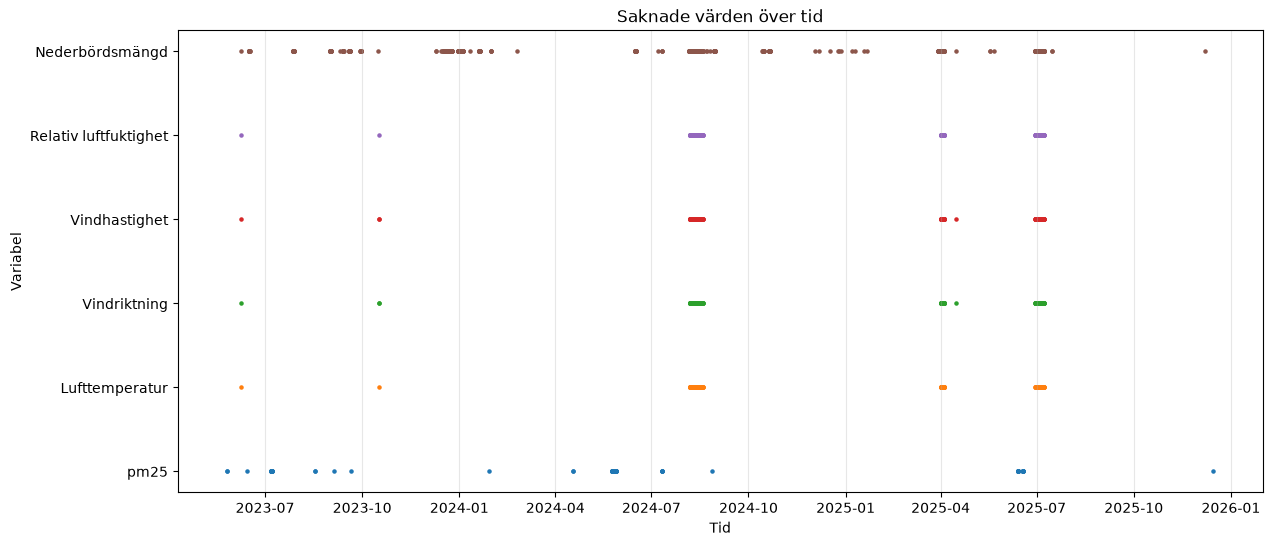

,Antal saknade variabler,Antal timmar
1,1,653
2,2,1
3,3,1
4,4,35
5,5,535


Empty DataFrame
Columns: [tid, pm25, Lufttemperatur, Vindriktning, Vindhastighet, Relativ luftfuktighet, Nederbördsmängd]
Index: []


,start,end,antal_timmar,Saknade variabler
0,2023-12-21 08:00:00+01:00,2023-12-22 19:00:00+01:00,36,Nederbördsmängd
1,2023-12-30 20:00:00+01:00,2024-01-01 07:00:00+01:00,36,Nederbördsmängd
2,2024-05-24 13:00:00+02:00,2024-05-28 09:00:00+02:00,93,pm25
3,2024-08-05 09:00:00+02:00,2024-08-18 13:00:00+02:00,317,Nederbördsmängd
4,2024-08-06 06:00:00+02:00,2024-08-18 13:00:00+02:00,296,"Lufttemperatur, Vindriktning, Vindhastighet, Relativ luftfuktighet"
5,2025-03-31 09:00:00+02:00,2025-04-04 12:00:00+02:00,100,Nederbördsmängd
6,2025-04-01 03:00:00+02:00,2025-04-04 12:00:00+02:00,82,"Vindriktning, Vindhastighet, Relativ luftfuktighet"
7,2025-06-29 09:00:00+02:00,2025-07-08 08:00:00+02:00,216,Nederbördsmängd
8,2025-06-29 19:00:00+02:00,2025-07-07 16:00:00+02:00,190,"Vindriktning, Vindhastighet, Relativ luftfuktighet"


,Variabel,Totalt saknade,Kan fyllas ≤3 h,Kvar efter 3 h,Kan fyllas ≤6 h,Kvar efter 6 h
0,pm25,154,12,142,17,137
1,Lufttemperatur,536,5,531,119,417
2,Vindriktning,572,4,568,4,568
3,Vindhastighet,572,4,568,4,568
4,Relativ luftfuktighet,570,2,568,2,568
5,Nederbördsmängd,1069,45,1024,45,1024


Antal timmar där nederbörd saknas: 1069

Hur ofta saknas även övriga vädervariabler?


Lufttemperatur           535
Vindriktning             570
Vindhastighet            570
Relativ luftfuktighet    569
dtype: int64

,start,end,antal_timmar,före,efter
0,2023-06-08 10:00:00+02:00,2023-06-08 10:00:00+02:00,1,0.0,0.0
4,2023-09-09 15:00:00+02:00,2023-09-09 15:00:00+02:00,1,0.0,0.0
8,2023-10-16 11:00:00+02:00,2023-10-16 11:00:00+02:00,1,0.0,0.0
9,2023-12-09 17:00:00+01:00,2023-12-09 18:00:00+01:00,2,0.2,0.0
10,2023-12-15 02:00:00+01:00,2023-12-15 03:00:00+01:00,2,0.0,0.0
12,2023-12-20 02:00:00+01:00,2023-12-20 03:00:00+01:00,2,0.0,0.0
14,2023-12-24 22:00:00+01:00,2023-12-24 23:00:00+01:00,2,1.9,0.0
15,2023-12-25 02:00:00+01:00,2023-12-25 04:00:00+01:00,3,0.0,0.0
18,2024-01-11 09:00:00+01:00,2024-01-11 09:00:00+01:00,1,0.0,0.0
20,2024-01-30 17:00:00+01:00,2024-01-30 18:00:00+01:00,2,0.0,0.0


,start,end,antal_timmar,före,efter
0,2023-06-08 10:00:00+02:00,2023-06-08 10:00:00+02:00,1,255.0,263.0
1,2023-10-17 09:00:00+02:00,2023-10-17 10:00:00+02:00,2,279.0,285.0
4,2025-04-15 15:00:00+02:00,2025-04-15 15:00:00+02:00,1,90.0,74.0


In [162]:
def find_nan_gaps(df: pd.DataFrame, column: str) -> pd.DataFrame:
    """Hittar sammanhängande perioder med saknade värden i en kolumn."""

    missing = df[column].isna()
    groups = missing.ne(missing.shift()).cumsum()

    gaps = (
        df[missing]
        .groupby(groups[missing])
        .agg(
            start=("tid", "first"),
            end=("tid", "last"),
            antal_timmar=("tid", "size")
        )
        .reset_index(drop=True)
    )

    return gaps


# Mätvariabler
value_columns = merged_df.columns.drop("tid")


# Sammanfatta längden på NaN-luckorna
summary = []

for column in value_columns:
    gaps = find_nan_gaps(merged_df, column)

    summary.append({
        "Variabel": column,
        "1 h": (gaps["antal_timmar"] == 1).sum(),
        "2 h": (gaps["antal_timmar"] == 2).sum(),
        "3 h": (gaps["antal_timmar"] == 3).sum(),
        "4–6 h": gaps["antal_timmar"].between(4, 6).sum(),
        "7–24 h": gaps["antal_timmar"].between(7, 24).sum(),
        "25h–168 h (≤1 week)": gaps["antal_timmar"].between(25, 168).sum(),
        ">168 h (>1 week)": (gaps["antal_timmar"] > 168).sum(),
        "Längsta lucka (h)": gaps["antal_timmar"].max()
    })

gap_summary = pd.DataFrame(summary)

display(gap_summary)


# Visualisera när de saknade värdena förekommer
plt.figure(figsize=(14, 6))

for i, column in enumerate(value_columns):
    missing = merged_df[column].isna()

    plt.scatter(
        merged_df.loc[missing, "tid"],
        [i] * missing.sum(),
        s=5
    )

plt.yticks(range(len(value_columns)), value_columns)
plt.xlabel("Tid")
plt.ylabel("Variabel")
plt.title("Saknade värden över tid")
plt.grid(axis="x", alpha=0.3)

plt.show()


# Antal saknade variabler per tidsstämpel,
# uppdelat efter vilken variabel som saknas
# missing_by_variable = (
#     merged_df[value_columns]
#     .isna()
#     .astype(int)
# )

# plt.figure(figsize=(14, 5))

# plt.stackplot(
#     merged_df["tid"],
#     *[missing_by_variable[column] for column in value_columns],
#     labels=value_columns
# )

# plt.xlabel("Tid")
# plt.ylabel("Antal saknade variabler")
# plt.title("Saknade värden per tidsstämpel och variabel")
# plt.yticks(range(len(value_columns) + 1))
# plt.legend(loc="upper left")
# plt.grid(alpha=0.3)

# plt.show()


# Antal saknade variabler vid varje timme
nan_per_timestamp = merged_df[value_columns].isna().sum(axis=1)

# Sammanställ antal timmar
missing_together = (
    nan_per_timestamp
    .value_counts()
    .sort_index()
    .rename_axis("Antal saknade variabler")
    .reset_index(name="Antal timmar")
)

# Visa bara timmar där minst ett värde saknas
missing_together = missing_together[
    missing_together["Antal saknade variabler"] > 0
]

display(missing_together)

# När inträffar den som saknar alla värden.
print(merged_df.loc[
    merged_df[value_columns].isna().sum(axis=1) == 6
])


long_gaps = []

for column in value_columns:
    gaps = find_nan_gaps(merged_df, column)

    gaps = gaps[gaps["antal_timmar"] > 24].copy()
    gaps["Variabel"] = column

    long_gaps.append(gaps)

long_gaps = pd.concat(long_gaps, ignore_index=True)

long_gaps = long_gaps[
    ["Variabel", "start", "end", "antal_timmar"]
]

long_gaps_grouped = (
    long_gaps
    .groupby(["start", "end", "antal_timmar"])["Variabel"]
    .agg(", ".join)
    .reset_index(name="Saknade variabler")
    .sort_values("start")
    .reset_index(drop=True)
)

pd.set_option("display.max_colwidth", None)

display(long_gaps_grouped)

#Kolla hur många värden som påverkas vid olika gränser: 
# Jämför hur många saknade värden som ligger i korta luckor
# vid olika möjliga gränser för interpolation

comparison = []

for column in value_columns:
    gaps = find_nan_gaps(merged_df, column)

    total_missing = gaps["antal_timmar"].sum()

    missing_max_3h = gaps.loc[
        gaps["antal_timmar"] <= 3, "antal_timmar"
    ].sum()

    missing_max_6h = gaps.loc[
        gaps["antal_timmar"] <= 6, "antal_timmar"
    ].sum()

    comparison.append({
        "Variabel": column,
        "Totalt saknade": total_missing,
        "Kan fyllas ≤3 h": missing_max_3h,
        "Kvar efter 3 h": total_missing - missing_max_3h,
        "Kan fyllas ≤6 h": missing_max_6h,
        "Kvar efter 6 h": total_missing - missing_max_6h
    })

interpolation_comparison = pd.DataFrame(comparison)

display(interpolation_comparison)


# Undersök vad som händer när nederbördsmängd saknas

rain_missing = merged_df[
    merged_df["Nederbördsmängd"].isna()
]

weather_columns = [
    "Lufttemperatur",
    "Vindriktning",
    "Vindhastighet",
    "Relativ luftfuktighet"
]

print("Antal timmar där nederbörd saknas:", len(rain_missing))

print("\nHur ofta saknas även övriga vädervariabler?")
display(
    rain_missing[weather_columns]
    .isna()
    .sum()
)

# Markera timmar där nederbörd saknas men temperatur finns
# Identifiera sammanhängande luckor i nederbördsdata
rain_gaps = find_nan_gaps(
    merged_df,
    "Nederbördsmängd"
)

# Lägg till nederbördsvärdet precis före och efter varje lucka
before_values = []
after_values = []

for _, gap in rain_gaps.iterrows():

    before = merged_df.loc[
        merged_df["tid"] < gap["start"],
        "Nederbördsmängd"
    ]

    after = merged_df.loc[
        merged_df["tid"] > gap["end"],
        "Nederbördsmängd"
    ]

    before_values.append(
        before.iloc[-1] if not before.empty else pd.NA
    )

    after_values.append(
        after.iloc[0] if not after.empty else pd.NA
    )

rain_gaps["före"] = before_values
rain_gaps["efter"] = after_values

# Visa bara korta luckor
short_rain_gaps = rain_gaps[
    rain_gaps["antal_timmar"] <= 3
]

display(short_rain_gaps)


wind_gaps = find_nan_gaps(
    merged_df,
    "Vindriktning"
)

short_wind_gaps = wind_gaps[
    wind_gaps["antal_timmar"] <= 3
].copy()

before_values = []
after_values = []

for _, gap in short_wind_gaps.iterrows():

    before = merged_df.loc[
        merged_df["tid"] < gap["start"],
        "Vindriktning"
    ]

    after = merged_df.loc[
        merged_df["tid"] > gap["end"],
        "Vindriktning"
    ]

    before_values.append(
        before.iloc[-1] if not before.empty else pd.NA
    )

    after_values.append(
        after.iloc[0] if not after.empty else pd.NA
    )

short_wind_gaps["före"] = before_values
short_wind_gaps["efter"] = after_values

display(short_wind_gaps)

## 7. Rimlighetskontroll av mätvärden

Variablernas fördelningar och extremvärden undersöks för att identifiera eventuella orimliga mätvärden.

**Observation:**  
De numeriska variablernas min- och maxvärden ligger inom rimliga intervall. Inga uppenbart orimliga värden identifieras i den deskriptiva statistiken.

PM2.5 varierar mellan 0,40 och 69,14 µg/m³. Maxvärdet ligger tydligt över medianen och övre kvartilen, men kan representera en faktisk kortvarig föroreningstopp. Höga PM2.5-värden bör därför inte automatiskt klassificeras som felaktiga enbart för att de är statistiska extremvärden.

Även vädervariablernas intervall framstår som rimliga. Ingen nederbörd är negativ, relativ luftfuktighet ligger mellan 19 och 99 %, och vindriktningen ligger inom intervallet 0–360°.

In [163]:
print("LUFTDATA (PM2.5)")
display(air_df.describe().round(2))

print("VÄDERDATA")
display(weather_df.describe().round(2))

print(air_df.nlargest(20, "pm25")[["tid", "pm25"]])

max_index = air_df["pm25"].idxmax()
max_tid = air_df.loc[max_index, "tid"]

around_max = air_df[
    air_df["tid"].between(
        max_tid - pd.Timedelta(hours=6),
        max_tid + pd.Timedelta(hours=6)
    )
]

print(around_max[["tid", "pm25"]])

LUFTDATA (PM2.5)


,pm25
count,22671.00
mean,7.52
std,6.26
min,0.40
25%,3.68
50%,5.72
75%,9.28
max,69.14


VÄDERDATA


,Lufttemperatur,Vindriktning,Vindhastighet,Relativ luftfuktighet,Nederbördsmängd
count,22289.00,22253.00,22253.00,22255.00,21756.00
mean,10.61,183.65,2.65,79.15,0.07
std,7.02,103.70,1.82,15.21,0.46
min,-12.10,0.00,0.00,19.00,0.00
25%,5.10,103.00,1.30,70.00,0.00
50%,10.60,199.00,2.40,84.00,0.00
75%,16.20,269.00,3.70,91.00,0.00
max,30.00,360.00,13.10,99.00,17.50


                            tid    pm25
6750  2024-03-02 07:00:00+01:00  69.138
5280  2024-01-01 01:00:00+01:00  59.741
6762  2024-03-02 19:00:00+01:00  59.724
4697  2023-12-07 18:00:00+01:00  59.130
6749  2024-03-02 06:00:00+01:00  58.491
4702  2023-12-07 23:00:00+01:00  58.391
6731  2024-03-01 12:00:00+01:00  57.934
4698  2023-12-07 19:00:00+01:00  57.174
6730  2024-03-01 11:00:00+01:00  56.826
6751  2024-03-02 08:00:00+01:00  56.643
6735  2024-03-01 16:00:00+01:00  55.128
15655 2025-03-08 08:00:00+01:00  54.852
6745  2024-03-02 02:00:00+01:00  54.795
6734  2024-03-01 15:00:00+01:00  54.565
15652 2025-03-08 05:00:00+01:00  54.516
4703  2023-12-08 00:00:00+01:00  54.338
15656 2025-03-08 09:00:00+01:00  54.102
6759  2024-03-02 16:00:00+01:00  53.989
6746  2024-03-02 03:00:00+01:00  53.918
7187  2024-03-20 12:00:00+01:00  53.907
                           tid    pm25
6744 2024-03-02 01:00:00+01:00  49.743
6745 2024-03-02 02:00:00+01:00  54.795
6746 2024-03-02 03:00:00+01:00  53.918
6747

### Fördelning och extremvärden för PM2.5

Fördelningen av PM2.5 är tydligt högerskev. Majoriteten av observationerna ligger på relativt låga nivåer, medan ett mindre antal observationer bildar en lång svans med höga värden.

IQR-metoden identifierar 1 350 observationer över den övre gränsen på 17,68 µg/m³. Dessa betraktas inte automatiskt som felaktiga mätvärden. Det högsta värdet, 69,14 µg/m³, omges av flera timmar med förhöjda nivåer, vilket talar för att det ingår i en faktisk föroreningsepisod.

Fördelningens skevhet bör beaktas vid den senare modellutvärderingen, eftersom modellens prestanda kan skilja sig mellan vanliga låga nivåer och mer ovanliga perioder med höga PM2.5-halter.


Nedre gräns: -4.71
Övre gräns: 17.68
Antal statistiska outliers: 1350


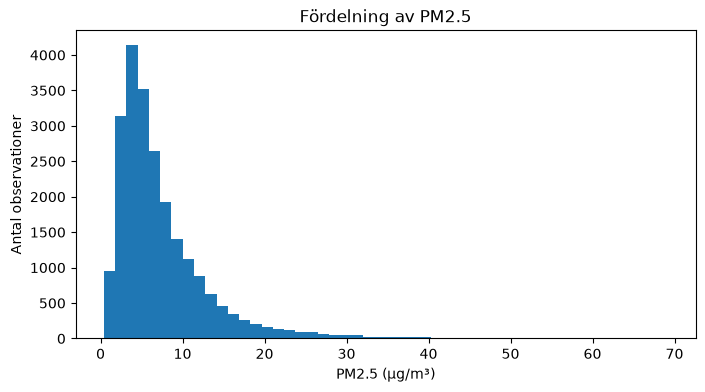

In [164]:
# Outliers
q1 = air_df["pm25"].quantile(0.25)
q3 = air_df["pm25"].quantile(0.75)

iqr = q3 - q1

lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

print("\nNedre gräns:", round(lower_limit, 2))
print("Övre gräns:", round(upper_limit, 2))

outliers = air_df[
    (air_df["pm25"] < lower_limit) |
    (air_df["pm25"] > upper_limit)
]

print("Antal statistiska outliers:", len(outliers))

plt.figure(figsize=(8, 4))
plt.hist(air_df["pm25"].dropna(), bins=50)

plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("Antal observationer")
plt.title("Fördelning av PM2.5")

plt.show()

## 8. Sammanfattning av datakvalitet och föreslagna åtgärder

Datakvalitetsanalysen har identifierat avvikelser i både PM2.5- och väderdatan. Vissa problem har åtgärdats i datahämtningen, medan andra behöver hanteras i den fortsatta bearbetningen och modelleringen.

### Åtgärdade problem

- **Datahämtning:** Hämtfunktionen för PM2.5 har korrigerats för att hantera dubbla tidsstämplar vid månadsskiften och säkerställa att observationerna ligger inom det angivna tidsintervallet.
- **Tidsformat:** Tidsstämplar konverteras till tidszonsmedvetna `datetime`-värden (`Europe/Stockholm`) i datapipelinen.

### Kvarvarande datakvalitetsfrågor

- **Saknade värden:** Både PM2.5- och väderdatan innehåller saknade observationer. Väderdata har dessutom längre bortfallsperioder och varierande rapporteringsfrekvens. Även när den sammanfogade datan har en komplett tidsaxel kan enskilda mätvärden saknas (`NaN`).
- **Vindriktning:** Värdena 0° och 360° representerar samma riktning och behöver hanteras som likvärdiga.
- **Extremvärden:** Höga PM2.5-värden kan representera verkliga föroreningsepisoder och bör inte automatiskt klassificeras som felaktiga enbart för att de avviker statistiskt.

### Konsekvenser för datapipelinen

1. **Datavalidering:** Tidsstämplar konverteras och sorteras, dubbletter kontrolleras, en komplett timaxel säkerställs och ogiltiga mätvärden markeras som `NaN`.

2. **Historisk analys:** Kortare luckor kan rekonstrueras med metoder anpassade efter respektive variabel. Längre sammanhängande luckor bör normalt lämnas som `NaN` för att undvika omfattande rekonstruktion av saknade observationer.

3. **Prognosmodellering:** Hanteringen av saknade värden, både i modellens indata och målvariabel, behöver utredas vidare med hänsyn till risken för informationsläckage.

## 9. Beslut om hantering av saknade värden

Analysen visar att saknade värden inte bör hanteras med en gemensam metod för samtliga variabler. Hanteringen behöver ta hänsyn till variabelns egenskaper, luckans längd och om bortfallet är en del av en längre period med reducerad datatillgänglighet. Dessutom behöver hänsyn tas till om datan ska användas för historisk analys eller prognosmodellering.

### Hantering av saknade värden i historiska data

För historisk interpolation definieras en **kort lucka som högst 3 sammanhängande timmar**. Gränsen väljs för att möjliggöra hantering av korta, isolerade bortfall utan att interpolera längre perioder med reducerad datatillgänglighet.

Analysen visar exempelvis att en gräns på 6 timmar skulle medföra att ett stort antal saknade temperaturvärden interpoleras under perioder där temperaturen endast rapporterats ungefär var sjätte timme.

| Variabel | Beslut för historisk interpolation |
|---|---|
| PM2.5 | Korta luckor på högst 3 timmar interpoleras linjärt. Längre luckor lämnas som `NaN`. |
| Lufttemperatur | Korta luckor på högst 3 timmar interpoleras linjärt. Längre luckor lämnas som `NaN`, vilket innebär att perioder med reducerad rapporteringsfrekvens inte fylls i större omfattning. |
| Vindhastighet | Korta luckor på högst 3 timmar interpoleras linjärt. Längre luckor lämnas som `NaN`. |
| Vindriktning | Korta luckor på högst 3 timmar interpoleras cirkulärt, eftersom 0° och 360° representerar samma riktning. Längre luckor lämnas som `NaN`. |
| Relativ luftfuktighet | Korta luckor på högst 3 timmar interpoleras linjärt. Längre luckor lämnas som `NaN`. |
| Nederbördsmängd | Korta luckor på högst 3 timmar fylls med 0 endast om nederbördsmängden är 0 både omedelbart före och efter luckan. Övriga saknade värden lämnas som `NaN`. |

### Kvarvarande saknade värden

Längre luckor lämnas kvar som `NaN` efter den variabelspecifika hanteringen. Perioder där flera vädervariabler saknas samtidigt ska inte rekonstrueras genom omfattande interpolation.

Kvarvarande `NaN` behålls i den bearbetade datan. Rådata och den ursprungliga sammanfogade datan behålls oförändrade.

### Hantering inför prognosmodellering

De valda interpoleringsmetoderna är främst avsedda för historisk analys och visualisering. Eftersom modellen ska förutsäga PM2.5 sex timmar framåt behöver hanteringen av saknade värden även ta hänsyn till vilken information som är tillgänglig vid prognostillfället.

Linjär och cirkulär interpolation använder observationer både före och efter en lucka, vilket kan medföra informationsläckage om metoderna används direkt på modellens indata.

Datavalidering och hantering av saknade värden inför modellering bör därför genomföras som separata steg. Den slutliga metoden för att hantera saknade värden i modellens indata och målvariabel behöver utvärderas i samband med modellutvecklingen.